# DQC Noise Analysis — Visualization Suite
Visualizes measurement distributions from the simulation CSV across noiseless and noisy configurations.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter
from scipy.stats import entropy as scipy_entropy

# ── Load CSV ──────────────────────────────────────────────────────────────────
CSV_PATH = "./results/12q_3qpu_noise100.csv"  # adjust as needed

df = pd.read_csv(CSV_PATH, dtype={'bitstring': str})
df['bitstring'] = df['bitstring'].astype(str)

# Zero-pad bitstrings that lost leading zeros during CSV round-trip
bit_width = df['bitstring'].str.len().max()
df['bitstring'] = df['bitstring'].str.zfill(bit_width)

print(f"Loaded {len(df)} rows | bit_width={bit_width}")
print(df['noise_label'].value_counts())
df.head()

Loaded 200 rows | bit_width=12
noise_label
Noiseless                    100
Noisy (2q=0.01, 1q=0.001)    100
Name: count, dtype: int64


,noise_label,two_q_depolar_prob,one_q_depolar_prob,run,bitstring,m_0,m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11
0,Noiseless,0.0,0.0,0,101111111111,1,0,1,1,1,1,1,1,1,1,1,1
1,Noiseless,0.0,0.0,1,101111111111,1,0,1,1,1,1,1,1,1,1,1,1
2,Noiseless,0.0,0.0,2,101111111111,1,0,1,1,1,1,1,1,1,1,1,1
3,Noiseless,0.0,0.0,3,101111111111,1,0,1,1,1,1,1,1,1,1,1,1
4,Noiseless,0.0,0.0,4,101111111111,1,0,1,1,1,1,1,1,1,1,1,1


In [39]:
# ── Build per-config summary ──────────────────────────────────────────────────
configs = []
for (noise_label, two_q, one_q), grp in df.groupby(
        ['noise_label', 'two_q_depolar_prob', 'one_q_depolar_prob']):
    counts = Counter(grp['bitstring'].tolist())
    num_runs = len(grp)
    probs = {k: v / num_runs for k, v in counts.items()}
    configs.append({
        'noise_label': noise_label,
        'two_q': float(two_q),
        'one_q': float(one_q),
        'counts': counts,
        'probs': probs,
        'num_runs': num_runs,
    })

# Sort noiseless first
configs.sort(key=lambda e: (e['two_q'], e['one_q']))

# Identify Target State bitstring from noiseless config
target_bitstring = None
ideal_probs = {}
for cfg in configs:
    if cfg['two_q'] == 0 and cfg['one_q'] == 0:
        target_bitstring = max(cfg['counts'], key=cfg['counts'].get)
        ideal_probs = cfg['probs']
        break

print(f"Target State bitstring: {target_bitstring}")
print(f"Noise configs: {[(c['noise_label'], c['two_q'], c['one_q']) for c in configs]}")

Target bitstring: 101111111111
Noise configs: [('Noiseless', 0.0, 0.0), ('Noisy (2q=0.01, 1q=0.001)', 0.01, 0.001)]


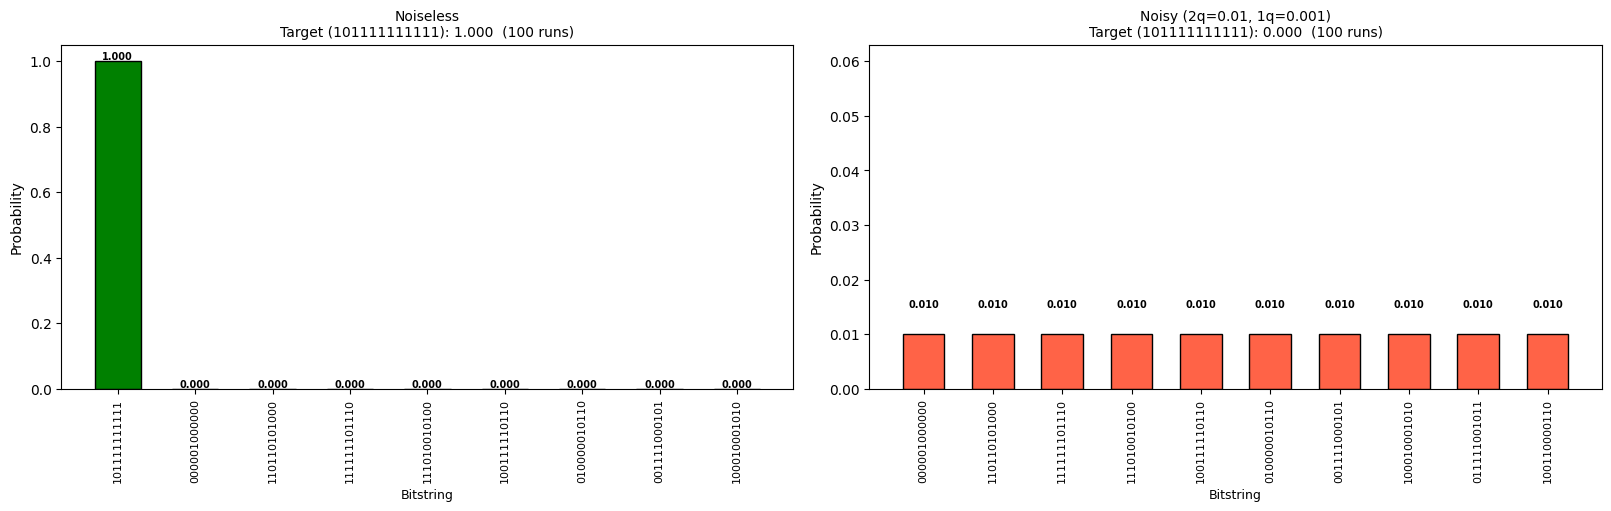

In [40]:
TOP_K = 10

n = len(configs)
fig, axes = plt.subplots(1, n, figsize=(8 * n, 5), constrained_layout=True)
if n == 1:
    axes = [axes]

for idx, (ax, cfg) in enumerate(zip(axes, configs)):
    probs = cfg['probs']
    sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    if not sorted_items:
        continue
    labels, values = zip(*sorted_items)
    labels, values = list(labels), list(values)

    # If noiseless, add bitstrings from noisy config with probability 0
    if cfg['noise_label'] == 'Noiseless' and idx + 1 < len(configs):
        noisy_probs = configs[idx + 1]['probs']
        existing_bitstrings = set(labels)
        additional_bitstrings = [bitstring for bitstring in noisy_probs.keys() if bitstring not in existing_bitstrings]
        additional_bitstrings = additional_bitstrings[:8]  # Add up to 4 more bars
        additional_values = [0.0] * len(additional_bitstrings)
        labels = labels + additional_bitstrings  # Concatenate as lists
        values = values + additional_values

    colors = ['green' if lbl == target_bitstring else 'tomato' for lbl in labels]
    x = list(range(len(labels)))
    ax.bar(x, values, width=0.6, color=colors, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_xlabel('Quantum State', fontsize=9)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, min(1.05, max(values) * 1.3 + 0.05) if max(values) > 0 else 1.0)
    target_prob = probs.get(target_bitstring, 0.0)
    ax.set_title(
        f"{cfg['noise_label']}\nTarget ({target_bitstring}): {target_prob:.3f}  ({cfg['num_runs']} runs)",
        fontsize=10)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=7, fontweight='bold')

# plt.suptitle('DQC Measurement Distribution: Noiseless vs Noisy', fontsize=13)
plt.savefig('./results/12q_3qpu.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Plot 1 — Histogram: Top-k Quantum State Probabilities per Config

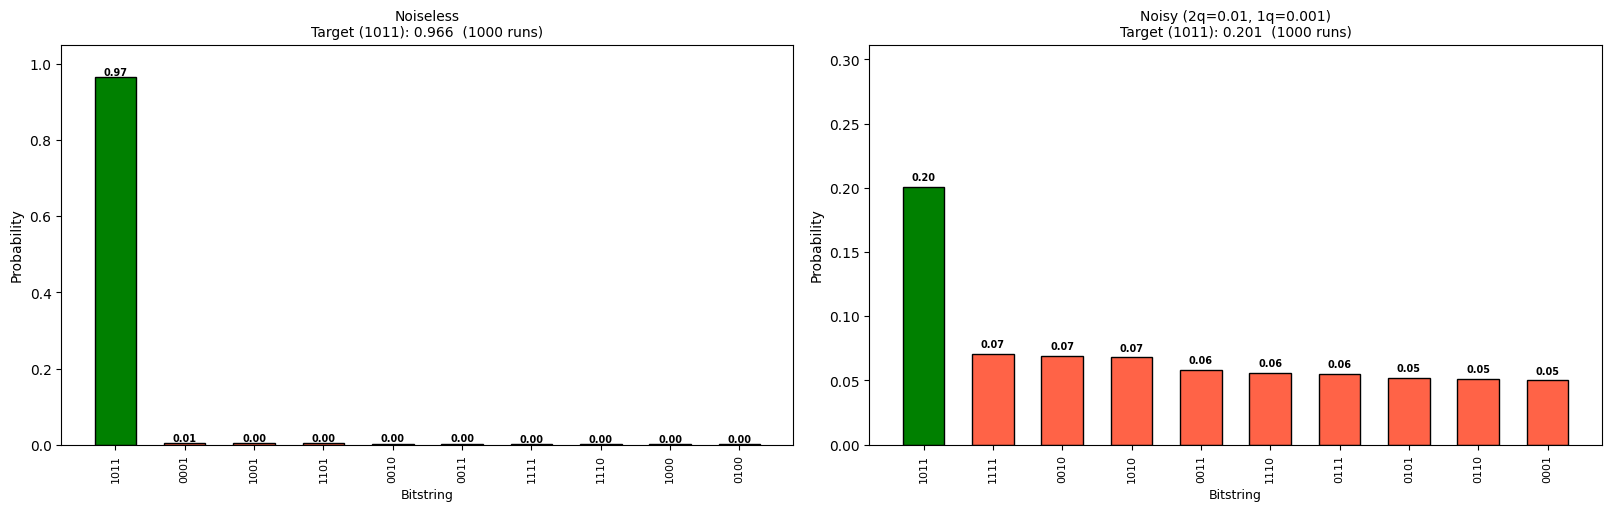

In [28]:
TOP_K = 10

n = len(configs)
fig, axes = plt.subplots(1, n, figsize=(8 * n, 5), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, cfg in zip(axes, configs):
    probs = cfg['probs']
    sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
    if not sorted_items:
        continue
    labels, values = zip(*sorted_items)
    labels, values = list(labels), list(values)
    colors = ['green' if lbl == target_bitstring else 'tomato' for lbl in labels]
    x = list(range(len(labels)))
    ax.bar(x, values, width=0.6, color=colors, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_xlabel('Quantum State', fontsize=9)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, min(1.05, max(values) * 1.3 + 0.05))
    target_prob = probs.get(target_bitstring, 0.0)
    ax.set_title(
        f"{cfg['noise_label']}\nTarget ({target_bitstring}): {target_prob:.3f}  ({cfg['num_runs']} runs)",
        fontsize=10)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')

# plt.suptitle('DQC Measurement Distribution: Noiseless vs Noisy', fontsize=13)
plt.savefig('./results/4q_3qpu.pdf', dpi=150, bbox_inches='tight')
plt.show()

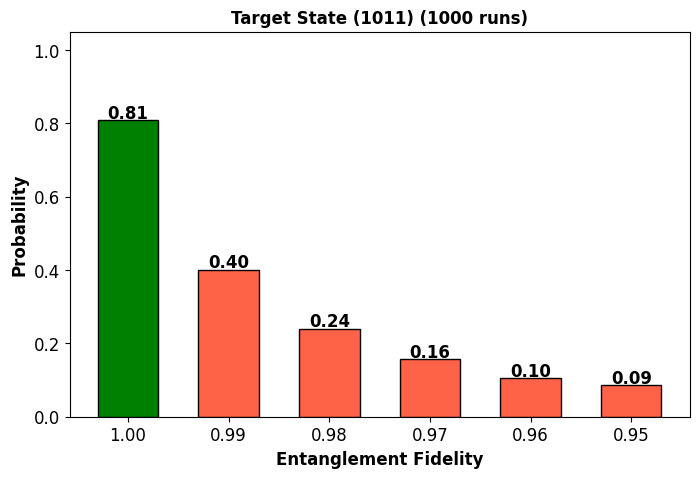

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# ==============================
# Config
# ==============================
csv_path = "./results/4q_3qpu_future.csv"
target_bitstring = "1011"

# ==============================
# Load + preprocess
# ==============================
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
df["bitstring"] = df["bitstring"].astype(str)

# Extract fidelity from noise_label
def extract_fidelity(label):
    match = re.search(r"F=([0-9.]+)", str(label))
    return float(match.group(1)) if match else 1.0

df["emission_fidelity"] = df["noise_label"].apply(extract_fidelity)

# ==============================
# Compute probabilities
# ==============================
grouped = df.groupby("emission_fidelity")

fidelities = []
probs = []
num_runs_list = []

for fid, group in grouped:
    total = len(group)
    count_target = (group["bitstring"] == target_bitstring).sum()
    prob = count_target / total

    fidelities.append(fid)
    probs.append(prob)
    num_runs_list.append(total)

# Sort (high → low fidelity)
fidelities, probs, num_runs_list = zip(*sorted(
    zip(fidelities, probs, num_runs_list), reverse=True
))

# ==============================
# Plot (matching your style)
# ==============================
fig, ax = plt.subplots(figsize=(8, 5))

x = list(range(len(fidelities)))

colors = ['green' if p == max(probs) else 'tomato' for p in probs]

ax.bar(x, probs, width=0.6, color=colors, edgecolor='black')

# X labels
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in fidelities], fontsize=12)

ax.set_xlabel('Entanglement Fidelity', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_ylim(0, min(1.05, max(probs) * 1.3 + 0.05))

# Title
ax.set_title(
    f"Target State ({target_bitstring}) (1000 runs)",
    fontsize=12, fontweight='bold'
)

# Annotate bars
for i, (p, runs) in enumerate(zip(probs, num_runs_list)):
    ax.text(i, p + 0.005, f'{p:.2f}', ha='center',
            fontsize=12, fontweight='bold')

# plt.suptitle('DQC Target State State Degradation with Entanglement Noise', fontsize=13)

plt.savefig('./results/4q_3qpu_future.pdf', dpi=150, bbox_inches='tight')
plt.show()

Selected runs: 1000


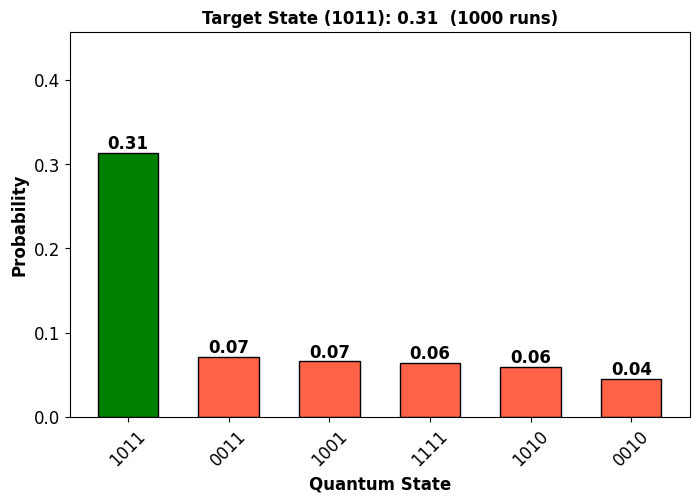

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
# ── GLOBAL FONT SETTINGS ───────────────────────────────
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
# ── Load CSV ─────────────────────────────────────────────
CSV_PATH = "./results/4q_1qpu_noise1000.csv"

df = pd.read_csv(CSV_PATH, dtype={'bitstring': str})
df['bitstring'] = df['bitstring'].astype(str)

# zero-pad
bit_width = df['bitstring'].str.len().max()
df['bitstring'] = df['bitstring'].str.zfill(bit_width)

# ── SELECT ONLY ONE CONFIG ───────────────────────────────
two_q_target = 0.01
one_q_target = 0.001

df_cfg = df[
    (df['two_q_depolar_prob'] == two_q_target) &
    (df['one_q_depolar_prob'] == one_q_target)
]

# ── sanity check ─────────────────────────────────────────
print(f"Selected runs: {len(df_cfg)}")

# ── build probabilities ──────────────────────────────────
counts = Counter(df_cfg['bitstring'])
num_runs = len(df_cfg)
probs = {k: v / num_runs for k, v in counts.items()}

target_bitstring = max(counts, key=counts.get)
target_prob = probs[target_bitstring]
# target_bitstring = "101111111111"
# target_prob = 0
# ── plot ────────────────────────────────────────────────
TOP_K = 6
fig, ax = plt.subplots(figsize=(8, 5))

sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)[:TOP_K]
labels, values = zip(*sorted_items)

labels = list(labels)
values = list(values)

colors = ['green' if lbl == target_bitstring else 'tomato' for lbl in labels]
x = list(range(len(labels)))

ax.bar(x, values, width=0.6, color=colors, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, rotation=45)
ax.set_xlabel('Quantum State', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold' )

ax.set_ylim(0, min(1.05, max(values) * 1.3 + 0.05))

ax.set_title(
    # f"Noisy (2q depol. = {two_q_target}, "
    # f"1q depol. = {one_q_target}, entl. fidelity = 1.0)\n"
    f"Target State ({target_bitstring}): {target_prob:.2f}  ({num_runs} runs)",
    fontsize=12, fontweight='bold'
)

for i, v in enumerate(values):
    ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
plt.savefig('./results/4q_1qpu.pdf', dpi=150, bbox_inches='tight')
plt.show()